In [15]:
import os
import scanpy as sc
import matplotlib.pyplot as plt

In [23]:
# central plot directory
PLOT_DIR = "results/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# 1. Load data

In [3]:
import scanpy as sc

adata = sc.read("results/annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 2700 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'celltype_celltypist', 'celltype_manual', 'cell_type', 'annotation_source'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

# 2. Core visualization

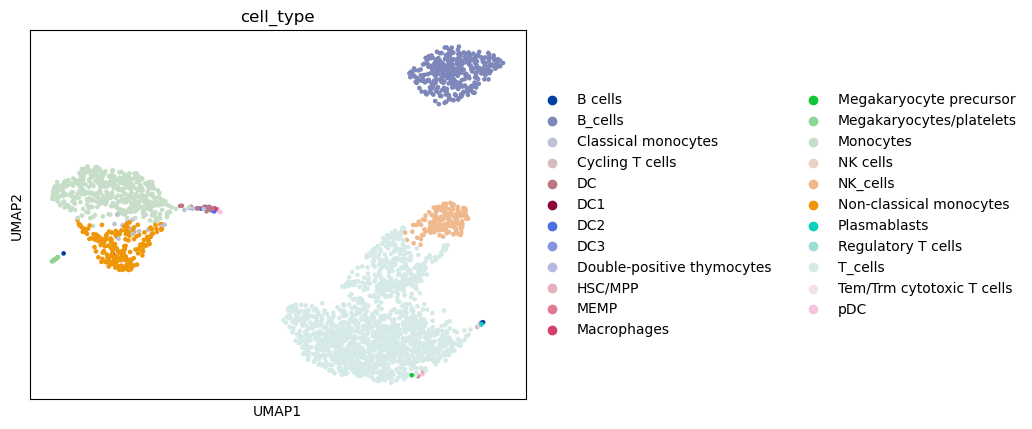

In [35]:
 # Cell types

fig = sc.pl.umap(adata, color="cell_type", show=False)

plt.savefig("results/plots/umap_celltype.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Infernece :
1. Distinct immune compartments identified: Major populations (B cells, T cells, monocytes, NK cells) form well-separated clusters, indicating robust clustering and biologically meaningful annotation.
2. Annotation redundancy present: Duplicate labels (e.g., B cells vs B_cells, NK cells vs NK_cells) suggest inconsistency in labeling, which needs harmonization.
3. Heterogeneity within lineages: Sub-structuring within large clusters (especially T cells and monocytes) indicates functional diversity (e.g., naïve vs effector states or classical vs non-classical subsets).

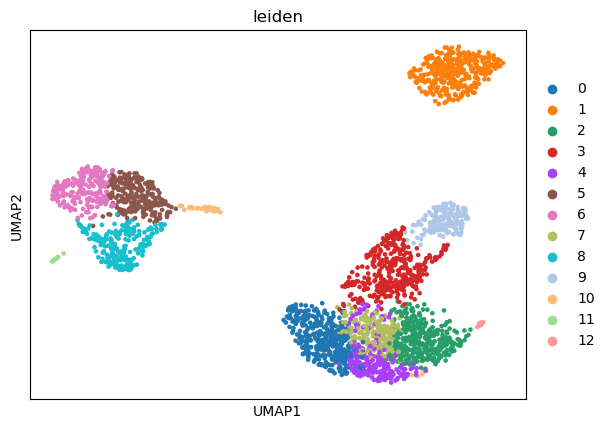

In [36]:
# Cell clusters

sc.pl.umap(adata, color="leiden", show=False)

plt.gcf().savefig("results/plots/cell_clusters.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Inference
1. Clear cluster separation indicates strong graph construction: Most clusters (e.g., 0, 1, 3, 9) are well-separated in UMAP space, suggesting that PCA + neighborhood graph captured meaningful biological variance.
2. Presence of cluster substructure and overlap: Central dense region (clusters ~4, 7, 8) shows partial mixing, indicating either transitional cell states or over-clustering at current resolution.
3. Potential rare populations detected: Small, isolated clusters (e.g., 11, 12) likely represent rare or specialized cell types, but require validation to rule out technical artifacts.

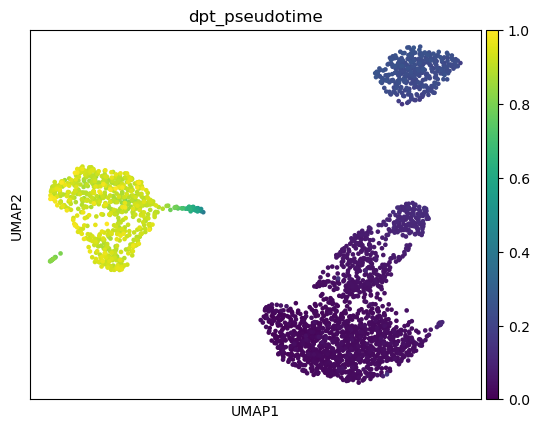

In [37]:
# Pseudotime
adata = sc.read("results/trajectory/trajectory.h5ad")

sc.pl.umap(adata, color="dpt_pseudotime", show=False)

plt.gcf().savefig("results/plots/pseudotime.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Inference :
1. Clear trajectory gradient: Smooth transition from low to high pseudotime indicates meaningful temporal ordering of cells.
2. Distinct lineage progression: One cluster shows early state while another represents terminal differentiation—suggesting biological progression.
3. Disconnected populations: Separate clusters without gradient likely represent independent lineages not involved in the same trajectory.

# Biological validation

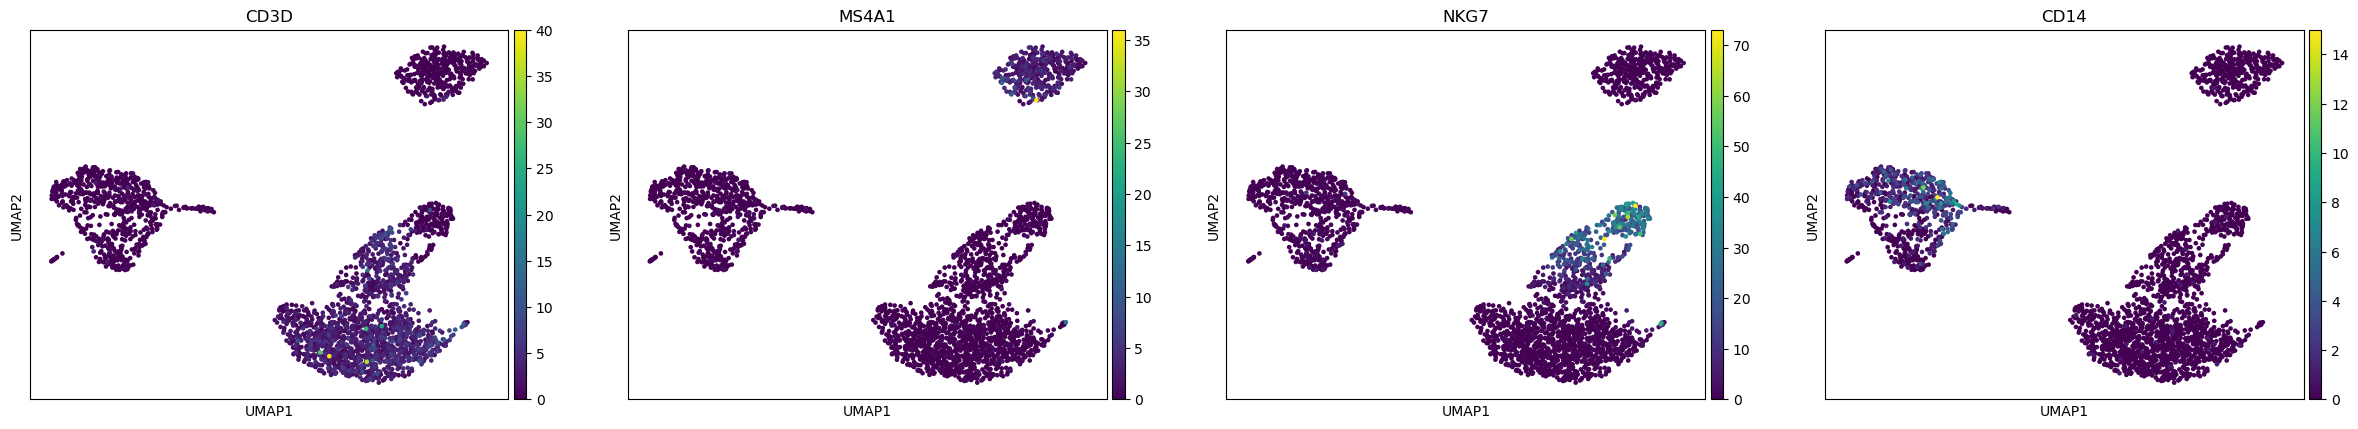

In [38]:
sc.pl.umap(
    adata,
    color=["CD3D", "MS4A1", "NKG7", "CD14"],
    show=False
)

plt.gcf().savefig(
    "results/plots/biological_validation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

# Inference :

1. Strong lineage-specific expression confirms annotation validity:
CD3D (T cells), MS4A1 (B cells), NKG7 (NK cells), and CD14 (monocytes) show spatially restricted expression, aligning well with expected immune compartments.
2. Minimal cross-lineage contamination:
Each marker is largely confined to distinct clusters with low background expression, indicating good data quality and minimal doublets or misclassification.
3. Functional heterogeneity within clusters:
Gradients of expression (especially NKG7 and CD14) suggest activation states or subpopulation diversity rather than uniform cell identity.

In [ ]:
# Dot plot

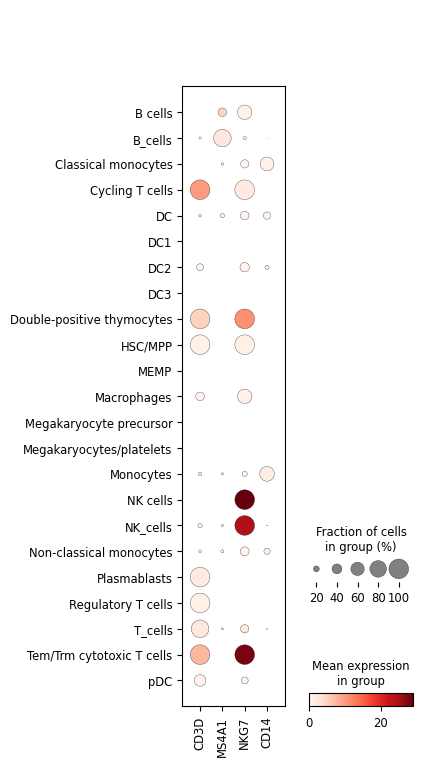

In [39]:

sc.pl.dotplot(
    adata,
    var_names=["CD3D", "MS4A1", "NKG7", "CD14"],
    groupby="cell_type",
    show=False
)

plt.gcf().savefig(
    "results/plots/dotplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

# Infernece :

1. Quantitative validation of markers: High expression and fraction (dot size + color) align with expected biology (e.g., NKG7 in NK cells).
2. Cell-type specificity confirmed: Marker enrichment is restricted to relevant cell populations, supporting annotation accuracy.
3. Redundant labeling detected: Duplicate labels (e.g., NK cells vs NK_cells, B cells vs B_cells) indicate need for annotation standardization.

In [ ]:
# Save results

In [22]:
adata.obs.to_csv("results/plots/cell_metadata.csv")

# # Conclusion

# 1. Robust cell population resolution achieved:
The pipeline successfully delineates major immune cell types with clear cluster separation and biologically meaningful structure, indicating strong preprocessing, dimensionality reduction, and clustering.

# 2. High-confidence annotation supported by marker validation:
Canonical markers (CD3D, MS4A1, NKG7, CD14) align precisely with predicted clusters, confirming the reliability of both reference-based (CellTypist) and manual annotation strategies.

# 3. Evidence of cellular heterogeneity and dynamic states:
Sub-clustering within major lineages and pseudotime gradients suggest functional diversity, including activation states and potential differentiation trajectories.

# 4. Minor technical inconsistencies remain:
Redundant labels (e.g., naming inconsistencies) and slight cluster overlap indicate the need for annotation harmonization and possible resolution tuning.

# 5. Pipeline is end-to-end functional and scalable:
The Nextflow workflow demonstrates reproducibility, modularity, and readiness for large-scale or multi-sample integration.